In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('C:/Users/Pc/Documents/ProjectCreditCardFraudDetection/data/raw/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(216075, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274992 entries, 0 to 274991
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    274992 non-null  float64
 1   V1      274992 non-null  float64
 2   V2      274992 non-null  float64
 3   V3      274992 non-null  float64
 4   V4      274992 non-null  float64
 5   V5      274992 non-null  float64
 6   V6      274992 non-null  float64
 7   V7      274992 non-null  float64
 8   V8      274992 non-null  float64
 9   V9      274992 non-null  float64
 10  V10     274992 non-null  float64
 11  V11     274992 non-null  float64
 12  V12     274992 non-null  float64
 13  V13     274992 non-null  float64
 14  V14     274992 non-null  float64
 15  V15     274992 non-null  float64
 16  V16     274991 non-null  float64
 17  V17     274991 non-null  float64
 18  V18     274991 non-null  float64
 19  V19     274991 non-null  float64
 20  V20     274991 non-null  float64
 21  V21     27

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(15)

In [8]:
df.duplicated().sum()

np.int64(1026)

In [9]:
df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
274991,166310.0,-0.582818,-1.083819,1.089951,-1.136101,-0.214613,1.837575,-0.953027,0.418515,-2.178887,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df[df.duplicated(keep=False)].sort_values(by='Time').head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0.0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0.0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0.0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0.0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0.0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0.0


In [11]:
# Guardamos el conteo original para comparar después
print("Filas antes de limpiar:",df.shape[0])
# 1. Eliminar la fila con nulos
df_clean = df.dropna()
# 2. Eliminar duplicados
df_clean = df_clean.drop_duplicates()
# 3. Convertir Class a entero
df_clean['Class'] = df_clean['Class'].astype(int)
print("Filas después de limpiar:", df_clean.shape[0])
print("Nulos restantes:", df_clean.isnull().sum().sum())
print("Duplicados restantes:", df_clean.duplicated().sum())

Filas antes de limpiar: 274992
Filas después de limpiar: 273965
Nulos restantes: 0
Duplicados restantes: 0


In [21]:
df_clean.to_csv('C:/Users/Pc/Documents/ProjectCreditCardFraudDetection/data/processed/creditcard_clean.csv', index=False)
print("Archivo guardado correctamente")

Archivo guardado correctamente


In [22]:
df_clean.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,...,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000,273965.000000
mean,92158.053357,0.001699,-0.014702,0.029263,0.002716,-0.009245,0.003775,-0.002818,-0.001499,-0.001633,...,-0.000538,-0.002884,-0.001276,0.000300,0.005082,0.000150,0.001806,0.000870,89.219104,0.001697
std,46152.568992,1.946777,1.648609,1.505097,1.414792,1.378736,1.331230,1.228734,1.177390,1.098438,...,0.726612,0.722179,0.627180,0.606004,0.519488,0.483128,0.395322,0.330127,251.837724,0.041163
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,53126.000000,-0.916533,-0.606529,-0.847232,-0.848755,-0.701319,-0.763858,-0.556451,-0.207071,-0.648844,...,-0.227183,-0.539756,-0.162493,-0.353735,-0.311097,-0.327776,-0.070445,-0.052141,5.850000,0.000000
50%,82183.000000,0.021987,0.059180,0.213506,-0.012983,-0.066180,-0.268692,0.034653,0.023067,-0.053550,...,-0.029968,0.004503,-0.012856,0.042102,0.025835,-0.054509,0.001755,0.011901,22.490000,0.000000
75%,136114.000000,1.303287,0.789242,1.048461,0.753718,0.599254,0.402378,0.563147,0.325014,0.599793,...,0.183560,0.519935,0.144947,0.437554,0.354200,0.242188,0.090382,0.077890,78.500000,0.000000
max,166310.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [23]:
df_clean.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,273500.0,89.162998,251.819268,0.0,5.9,22.50,78.38,25691.16
1,465.0,122.219097,260.661913,0.0,1.0,9.13,104.81,2125.87


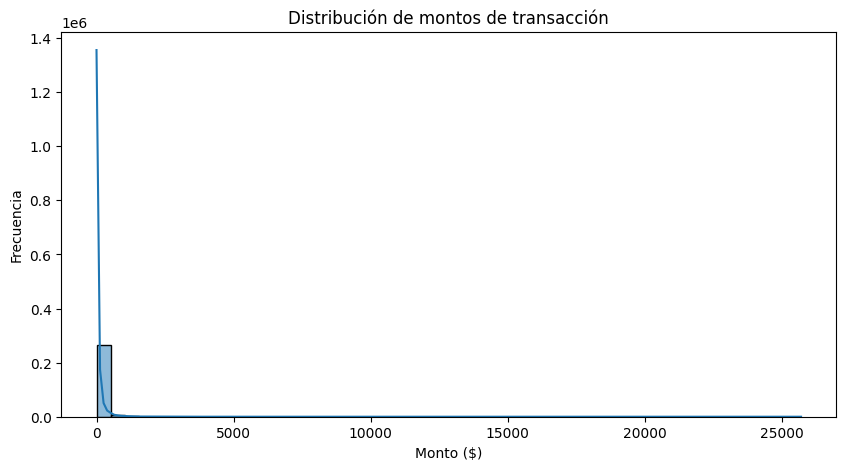

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['Amount'], bins=50, kde=True)
plt.title('Distribución de montos de transacción')
plt.xlabel('Monto ($)')
plt.ylabel('Frecuencia')
plt.show()

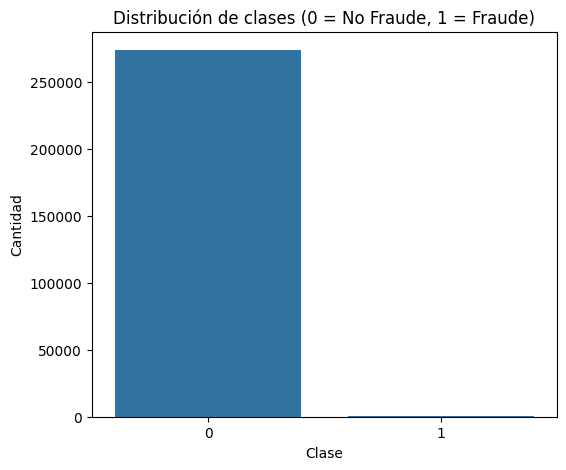

In [25]:
plt.figure(figsize=(6,5))
sns.countplot(x='Class', data=df_clean)
plt.title('Distribución de clases (0 = No Fraude, 1 = Fraude)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

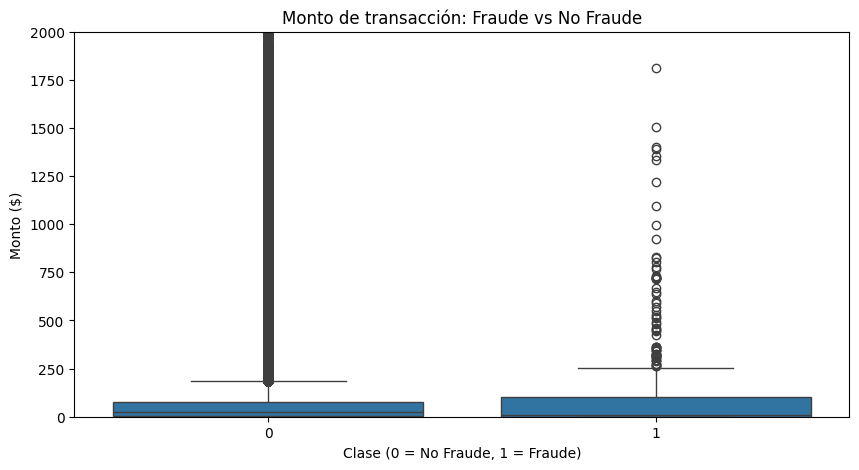

In [26]:
#Boxplot de montos por clase
plt.figure(figsize=(10,5))
sns.boxplot(x='Class', y='Amount', data=df_clean)
plt.title('Monto de transacción: Fraude vs No Fraude')
plt.xlabel('Clase (0 = No Fraude, 1 = Fraude)')
plt.ylabel('Monto ($)')
plt.ylim(0, 2000)  # limitamos el eje para poder ver bien las cajas
plt.show()

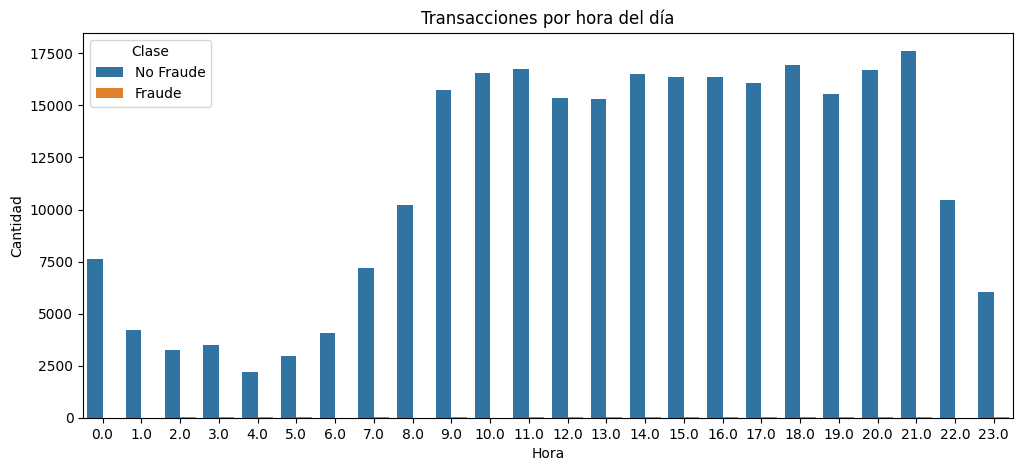

In [27]:
#Fraude a lo largo del tiempo
plt.figure(figsize=(12,5))
df_clean['Hour'] = (df_clean['Time'] // 3600) % 24
sns.countplot(x='Hour', hue='Class', data=df_clean)
plt.title('Transacciones por hora del día')
plt.xlabel('Hora')
plt.ylabel('Cantidad')
plt.legend(title='Clase', labels=['No Fraude','Fraude'])
plt.show()

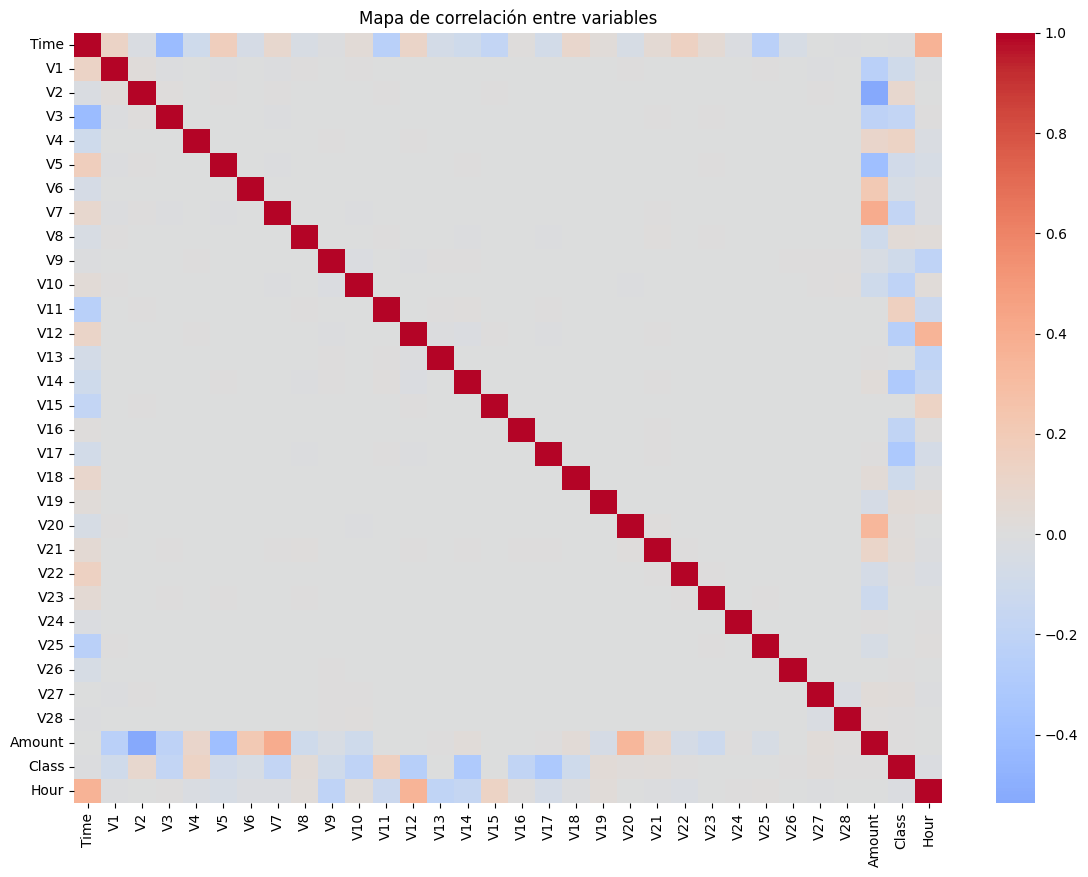

In [29]:
#Mapa de correlación
plt.figure(figsize=(14,10))
corr = df_clean.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Mapa de correlación entre variables')
plt.show()

In [30]:
#variables más correlacionadas con fraude
corr['Class'].sort_values(ascending=False)

Class     1.000000
V11       0.151136
V4        0.131976
V2        0.086741
V19       0.034089
V8        0.034014
V21       0.026788
V27       0.021833
V20       0.021566
V28       0.009769
Amount    0.005403
V22       0.004964
V26       0.004154
V25       0.002864
V13      -0.003461
V15      -0.003610
V23      -0.006498
V24      -0.007510
Time     -0.011815
Hour     -0.016431
V6       -0.044840
V5       -0.089411
V9       -0.095668
V1       -0.096784
V18      -0.107447
V7       -0.176243
V3       -0.186781
V16      -0.190618
V10      -0.211383
V12      -0.252943
V14      -0.298081
V17      -0.318721
Name: Class, dtype: float64

## Conclusiones del EDA

- El dataset tiene 273,965 transacciones limpias (se eliminaron 1 fila con nulos y 1,026 duplicados).
- Fuerte desbalance de clases: 99.82% no fraude vs 0.18% fraude (~480 casos).
- El monto (`Amount`) y la hora (`Hour`) tienen correlación casi nula con el fraude — no son buenos predictores por sí solos.
- Las variables con mayor correlación con fraude son V17, V14, V12 (negativas) y V11, V4 (positivas) — componentes de PCA que capturan patrones de comportamiento no directamente interpretables.
- Las transacciones fraudulentas tienden a tener montos más comprimidos (menos outliers extremos) que las transacciones normales.

In [8]:
df_check = pd.read_csv('../data/processed/creditcard_clean.csv')
print(df_check.columns.tolist())
print(len(df_check.columns)) 

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
31
